In [1256]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from iminuit import Minuit
from iminuit.cost import LeastSquares

from scipy.stats import chi2
from scipy.optimize import fmin
from scipy.optimize import fsolve

In [1257]:
def fit_model(x, A, B):
    return A*np.exp(x*B)

T = np.array([0, 10, 20, 30, 40])                       # °C
eta = np.array([1793.0, 1307.0, 1002.0, 797.7, 653.2])  # μPa s
err_eta = 0.05*eta

least_squares_mode = LeastSquares(T, eta, err_eta, fit_model)
m = Minuit(least_squares_mode, *[0,0], name=("A", "B"))
m.migrad()
m.hesse()
m.minos()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.087 (χ²/ndof = 0.7)      │              Nfcn = 123              │
│ EDM = 2.59e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  1.72e3   │  0.07e3   │  -0.07e3   │   0.07e3   │         │         │       │
│ 1 │ B    │  -0.0251  │  0.0017   │  -0.0017   │   0.0016   │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │           A           │           B           │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -70    │    70     │  -0.0017  │  0.0017   │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────┐
│   │           A           B │
├───┼─────────────────────────┤
│ A │    4.69e+03 -93.4923e-3 │
│ B │ -93.4923e-3    2.72e-06 │
└───┴─────────────────────────┘

In [1258]:
A = m.values[0]           # μPa s
err_A = m.errors[0]       # μPa s 
                             
B = m.values[1]           # (°C)^-1
err_B = m.errors[1]       # (°C)^-1
                             
T = 25                    # °C
                          
ETA = fit_model(T, A, B)  # μPa s
ERR_ETA = np.sqrt(
    (ETA/A * err_A)**2 + 
    (B * ETA * err_B)**2
)

print(f"Viscosity η: {ETA:.2f} ± {ERR_ETA:.2f}")

Viscosity η: 916.82 ± 36.55


In [1259]:
def model_lin(x, m):
    return m*x

In [1260]:
inputfile = "data/acqua/01_1.csv"

df = pd.read_csv(inputfile)
df

,t,x,y
0,0.00,287.0,59.46
1,0.05,284.7,59.69
2,0.10,285.6,59.63
3,0.15,287.7,56.78
4,0.20,287.1,56.43
...,...,...,...
995,49.75,310.5,41.78
996,49.80,309.6,41.94
997,49.85,310.7,42.42
998,49.90,312.0,45.44


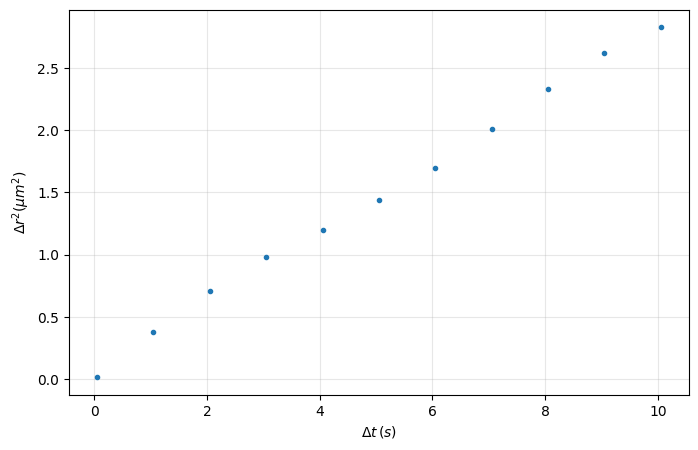

In [1261]:
def msd_calculation(filepath, max_lag):
    df = pd.read_csv(filepath)

    # Calibrazione pixel (dal paper)
    pixel_size = 0.06841  # μm


    msd = []
    dt = []

    t0 = df['t'].iloc[1] - df['t'].iloc[0]

    for lag in range(1, max_lag+10, 20):   

        dx = df['x'].diff(periods=lag)*pixel_size
        dy = df['y'].diff(periods=lag)*pixel_size

        dr2 = dx**2 + dy**2

        msd.append(dr2.mean())
        dt.append(lag * t0)

    return np.array(msd), np.array(dt)

max_lag = 200

msd, dt = msd_calculation(inputfile, max_lag)

plt.figure(figsize=(8,5))
plt.plot(dt, msd, '.')
plt.xlabel('$\\Delta t \\, (s)$')
plt.ylabel('$\\Delta r^2 (\\mu m^2)$')
plt.grid(alpha=0.3)
plt.show()

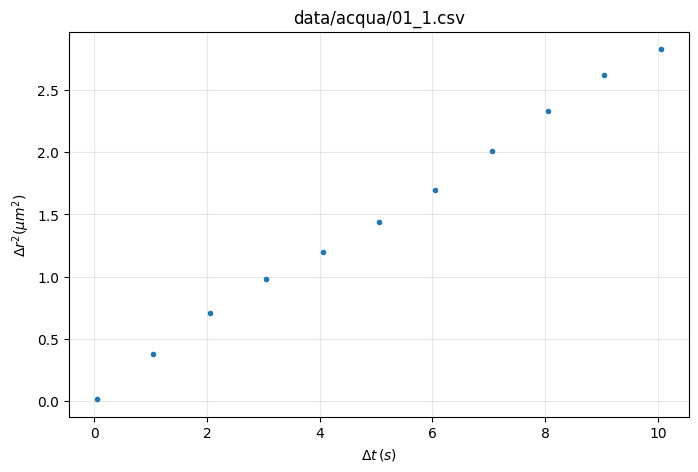

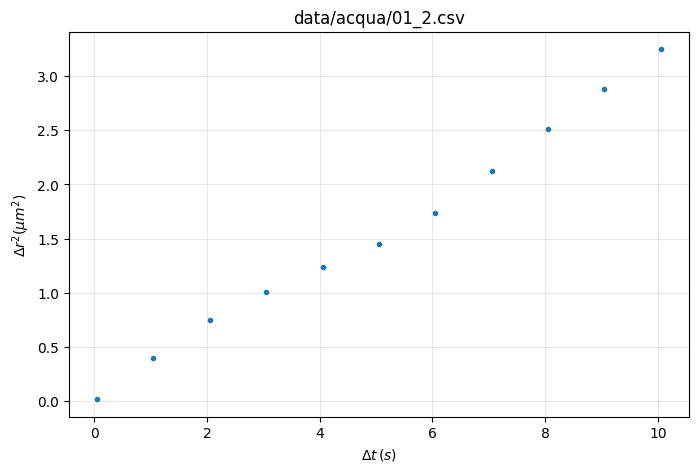

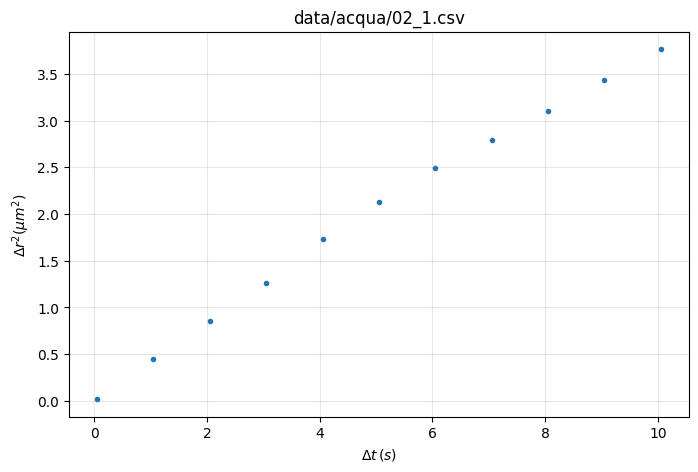

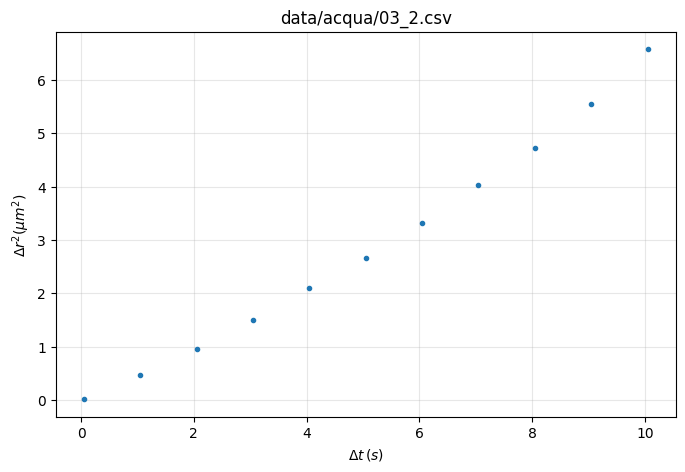

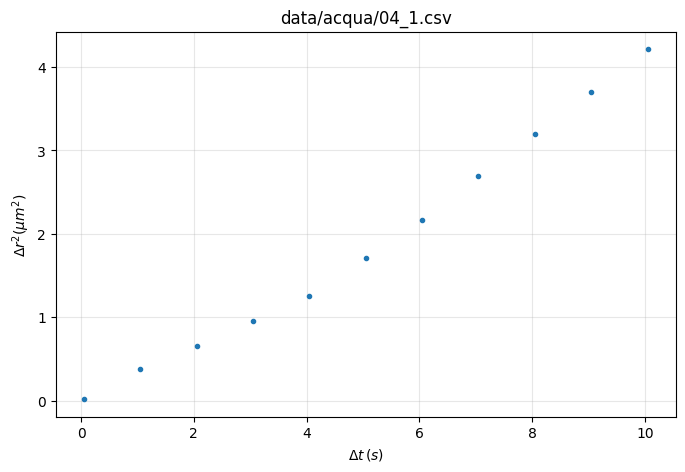

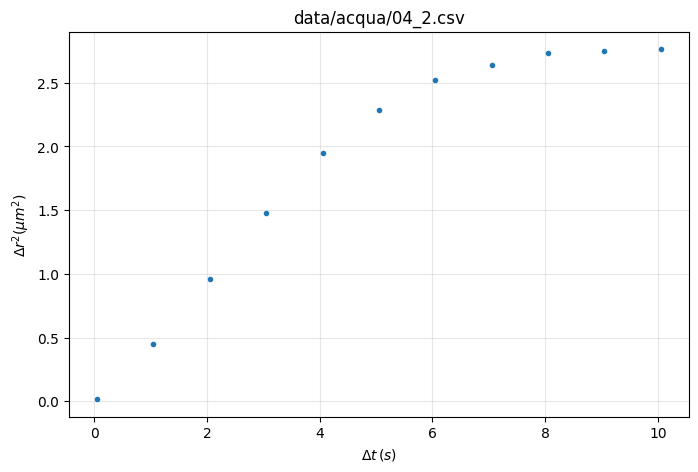

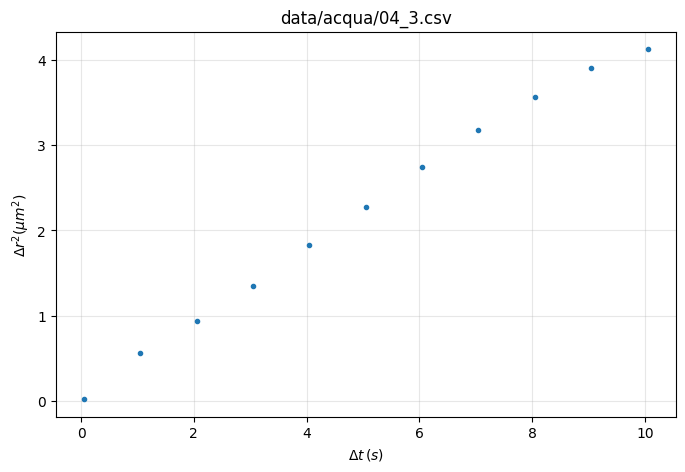

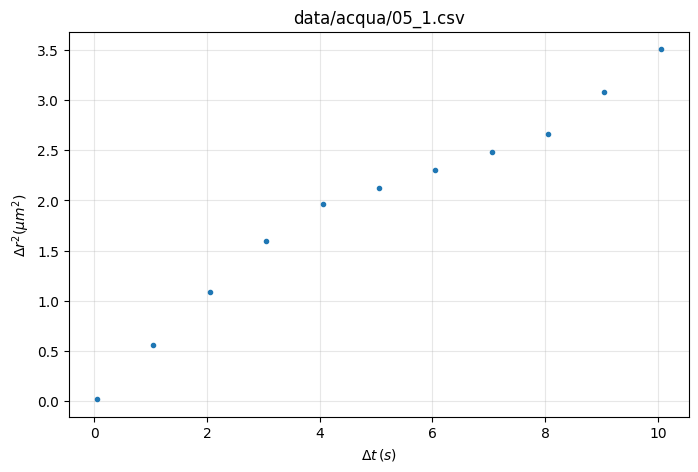

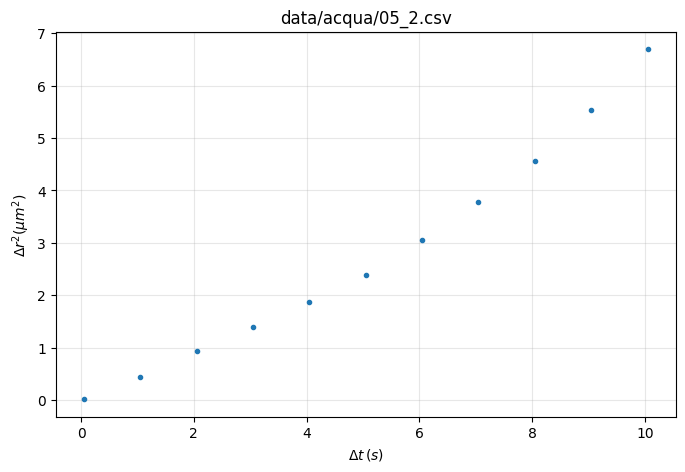

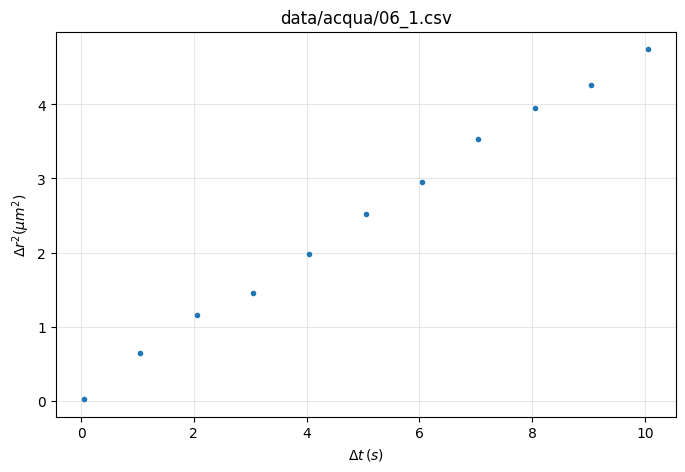

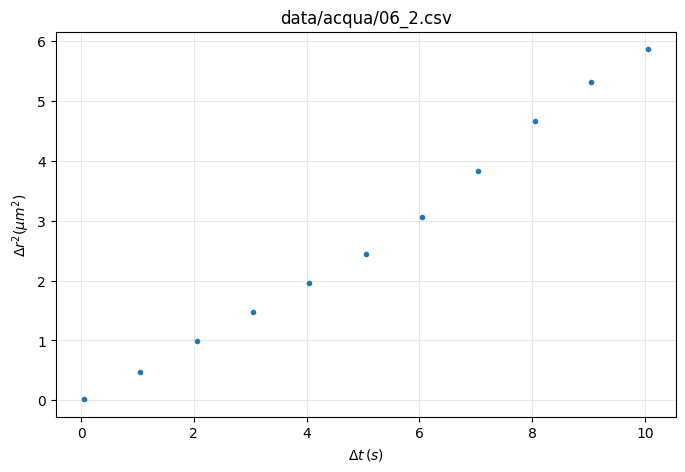

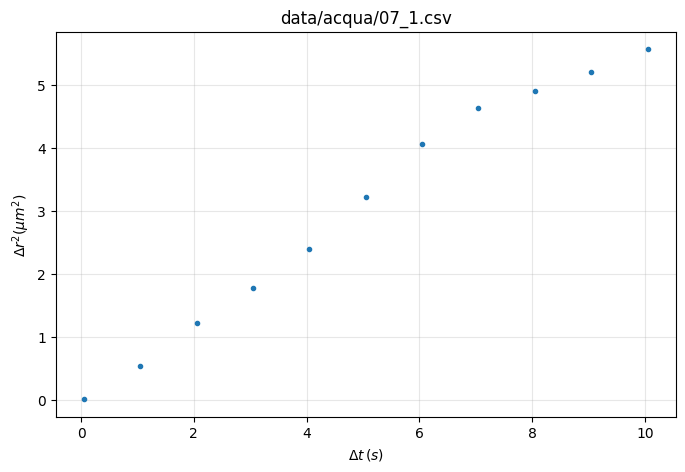

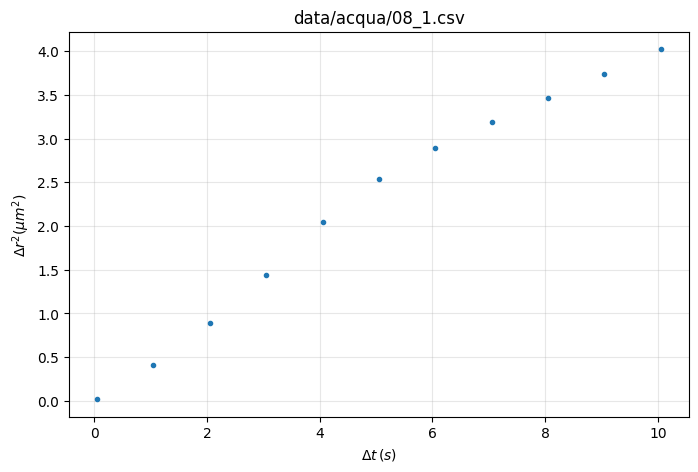

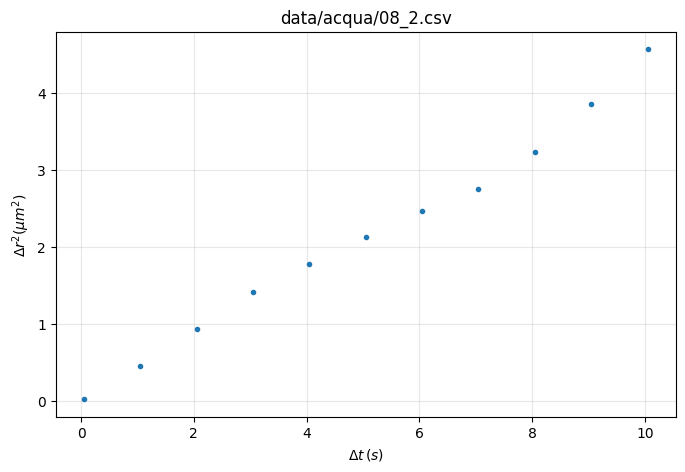

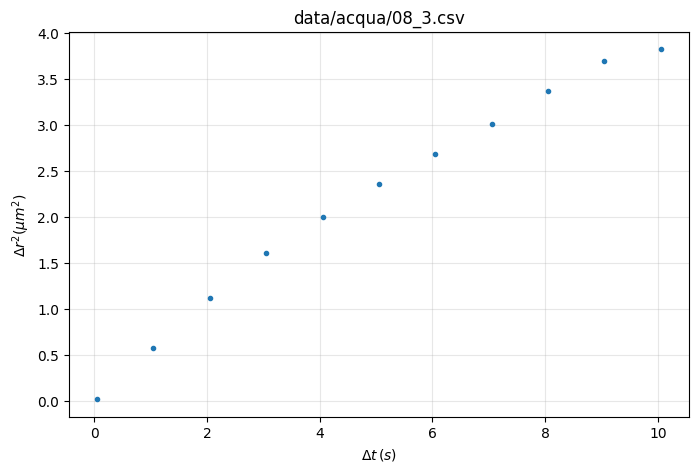

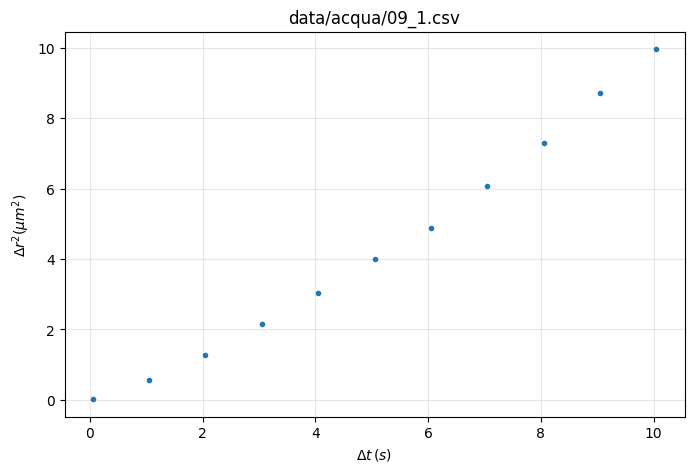

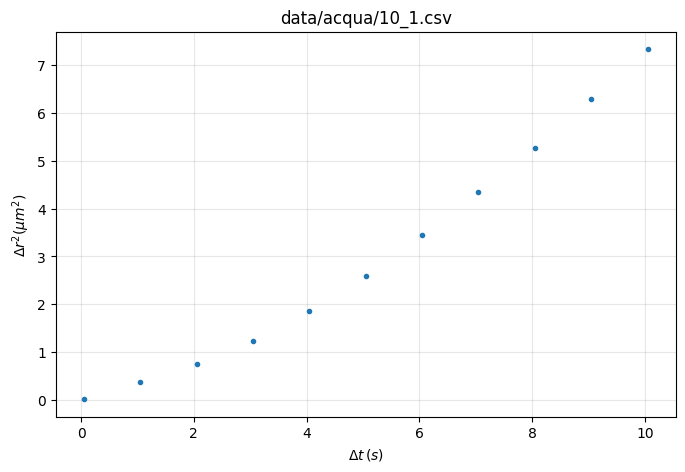

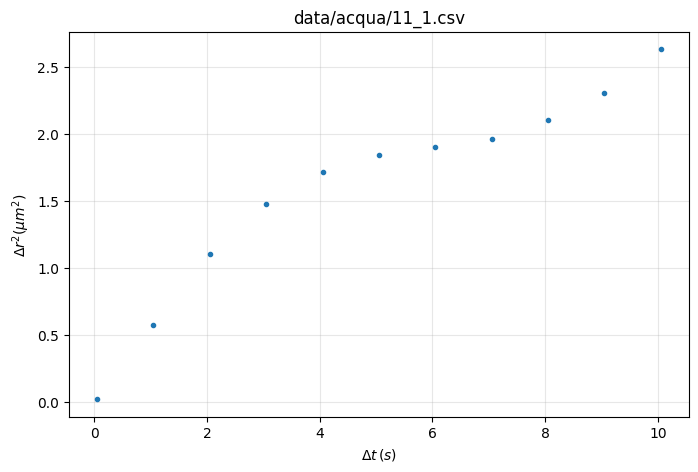

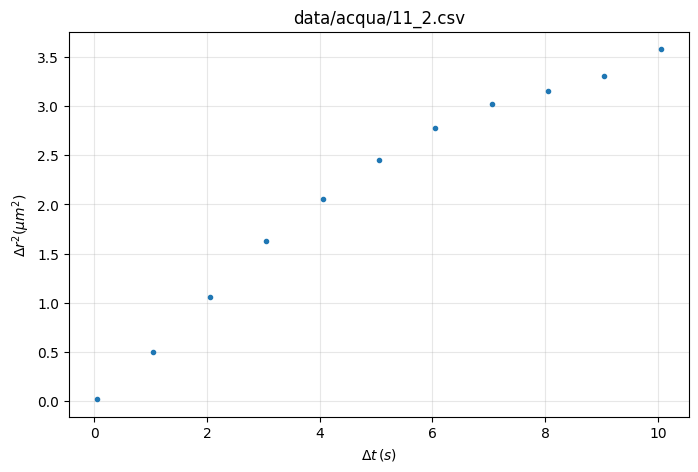

,dt,msd_1,msd_2,msd_3,msd_4,msd_5,msd_6,msd_7,msd_8,msd_9,msd_10,msd_11,msd_12,msd_13,msd_14,msd_15,msd_16,msd_17,msd_18,msd_19
0,0.05,0.013896,0.016775,0.018706,0.014683,0.015340,0.015420,0.018464,0.018290,0.016999,0.019331,0.018374,0.016529,0.018082,0.016943,0.020926,0.017925,0.014245,0.018238,0.017573
1,1.05,0.375940,0.401556,0.449420,0.473039,0.372166,0.448100,0.561597,0.557181,0.447898,0.648805,0.468531,0.549370,0.412583,0.445013,0.581331,0.570383,0.374373,0.573869,0.498810
2,2.05,0.706645,0.745294,0.853029,0.957132,0.648241,0.960064,0.936687,1.089814,0.927495,1.150779,0.987581,1.228704,0.895963,0.932283,1.125469,1.285019,0.757221,1.104401,1.056447
3,3.05,0.982677,1.007328,1.258551,1.491530,0.957248,1.475993,1.345770,1.592863,1.390677,1.454788,1.481486,1.773973,1.443374,1.407438,1.610403,2.156651,1.238627,1.477975,1.624227
4,4.05,1.201147,1.240262,1.729455,2.092023,1.254476,1.950127,1.825379,1.964499,1.862934,1.981900,1.957170,2.403947,2.041928,1.772646,2.003697,3.047425,1.859130,1.714694,2.059230
5,5.05,1.439925,1.448759,2.128516,2.662373,1.706070,2.286029,2.273936,2.127563,2.391487,2.523525,2.448275,3.218274,2.539060,2.132555,2.363041,3.986299,2.593396,1.842870,2.449032
6,6.05,1.695846,1.733728,2.490920,3.318330,2.164830,2.525156,2.740087,2.299107,3.060312,2.946713,3.069437,4.073781,2.892229,2.458226,2.687779,4.889291,3.440050,1.905852,2.774610
7,7.05,2.011593,2.126280,2.795870,4.034168,2.688497,2.642713,3.181465,2.482623,3.781390,3.529356,3.831485,4.637579,3.194286,2.755738,3.015794,6.059193,4.340196,1.960402,3.022704
8,8.05,2.334026,2.514139,3.097999,4.721905,3.194597,2.731730,3.571723,2.659286,4.570910,3.955033,4.660315,4.900988,3.460722,3.233676,3.375740,7.306699,5.269782,2.103363,3.155865
9,9.05,2.623808,2.882530,3.434040,5.550739,3.704697,2.745616,3.901103,3.077762,5.538852,4.263596,5.320364,5.211862,3.742419,3.861117,3.700179,8.700161,6.287550,2.308870,3.302332


In [1281]:
INPUT_DIR = "data/acqua"

df = None 

for i, input_file_name in enumerate(sorted(os.listdir(INPUT_DIR))):
    input_file_path = os.path.join(INPUT_DIR, input_file_name)

    msd, dt = msd_calculation(input_file_path, max_lag)

    plt.figure(figsize=(8,5))
    plt.plot(dt, msd, '.')
    plt.xlabel('$\\Delta t \\, (s)$')
    plt.ylabel('$\\Delta r^2 (\\mu m^2)$')
    plt.title(input_file_path)
    plt.grid(alpha=0.3)
    plt.show()

    col_name = f"msd_{i+1}"  # oppure usa il nome del file

    if df is None:
        # prima iterazione: crea il DataFrame con dt
        df = pd.DataFrame({
            "dt": dt,
            col_name: msd
        })
    else:
        # aggiunge solo la nuova colonna msd
        df[col_name] = msd

df

In [1263]:
df["msd_mean"] = df.drop(columns="dt").mean(axis=1)
df["msd_sem"] = df.drop(columns="dt").std(axis=1)
df

,dt,msd_1,msd_2,msd_3,msd_4,msd_5,msd_6,msd_7,msd_8,msd_9,...,msd_12,msd_13,msd_14,msd_15,msd_16,msd_17,msd_18,msd_19,msd_mean,msd_sem
0,0.05,0.013896,0.016775,0.018706,0.014683,0.015340,0.015420,0.018464,0.018290,0.016999,...,0.016529,0.018082,0.016943,0.020926,0.017925,0.014245,0.018238,0.017573,0.017197,0.001788
1,1.05,0.375940,0.401556,0.449420,0.473039,0.372166,0.448100,0.561597,0.557181,0.447898,...,0.549370,0.412583,0.445013,0.581331,0.570383,0.374373,0.573869,0.498810,0.484735,0.080065
2,2.05,0.706645,0.745294,0.853029,0.957132,0.648241,0.960064,0.936687,1.089814,0.927495,...,1.228704,0.895963,0.932283,1.125469,1.285019,0.757221,1.104401,1.056447,0.965698,0.170955
3,3.05,0.982677,1.007328,1.258551,1.491530,0.957248,1.475993,1.345770,1.592863,1.390677,...,1.773973,1.443374,1.407438,1.610403,2.156651,1.238627,1.477975,1.624227,1.430083,0.274552
4,4.05,1.201147,1.240262,1.729455,2.092023,1.254476,1.950127,1.825379,1.964499,1.862934,...,2.403947,2.041928,1.772646,2.003697,3.047425,1.859130,1.714694,2.059230,1.892741,0.404444
5,5.05,1.439925,1.448759,2.128516,2.662373,1.706070,2.286029,2.273936,2.127563,2.391487,...,3.218274,2.539060,2.132555,2.363041,3.986299,2.593396,1.842870,2.449032,2.345315,0.568608
6,6.05,1.695846,1.733728,2.490920,3.318330,2.164830,2.525156,2.740087,2.299107,3.060312,...,4.073781,2.892229,2.458226,2.687779,4.889291,3.440050,1.905852,2.774610,2.798226,0.759187
7,7.05,2.011593,2.126280,2.795870,4.034168,2.688497,2.642713,3.181465,2.482623,3.781390,...,4.637579,3.194286,2.755738,3.015794,6.059193,4.340196,1.960402,3.022704,3.267965,0.989685
8,8.05,2.334026,2.514139,3.097999,4.721905,3.194597,2.731730,3.571723,2.659286,4.570910,...,4.900988,3.460722,3.233676,3.375740,7.306699,5.269782,2.103363,3.155865,3.727289,1.232093
9,9.05,2.623808,2.882530,3.434040,5.550739,3.704697,2.745616,3.901103,3.077762,5.538852,...,5.211862,3.742419,3.861117,3.700179,8.700161,6.287550,2.308870,3.302332,4.218821,1.521341


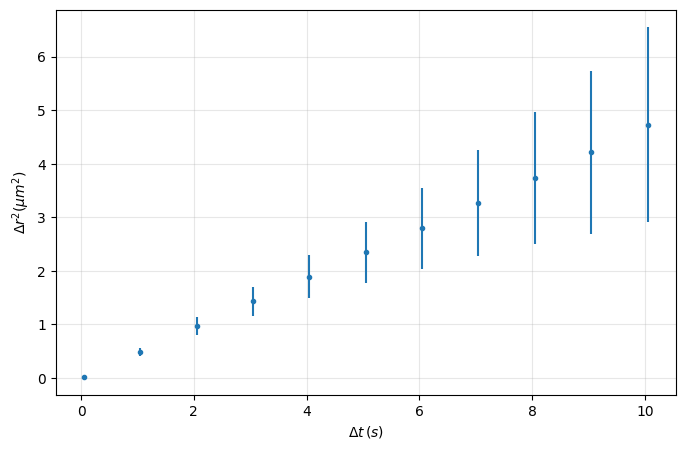

In [1264]:
x = df["dt"]
y = df["msd_mean"]
err_y = df["msd_sem"]

plt.figure(figsize=(8,5))
plt.errorbar(x, y, yerr=err_y, fmt='.')
plt.xlabel('$\\Delta t \\, (s)$')
plt.ylabel('$\\Delta r^2 (\\mu m^2)$')
plt.grid(alpha=0.3)
plt.show()

In [1265]:
least_squares_mode_lin = LeastSquares(x, y, err_y, model_lin)
m_lin = Minuit(least_squares_mode_lin, 1000, name=("m"))
m_lin.migrad()
m_lin.hesse()
m_lin.minos()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.051 (χ²/ndof = 0.6)      │              Nfcn = 22               │
│ EDM = 2.73e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ m    │   0.407   │   0.025   │   -0.025   │   0.025    │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │           m           │
├──────────┼───────────┬───────────┤
│  Error   │  -0.025   │   0.025   │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───┬──────────┐
│   │        m │
├───┼──────────┤
│ m │ 0.000616 │
└───┴──────────┘

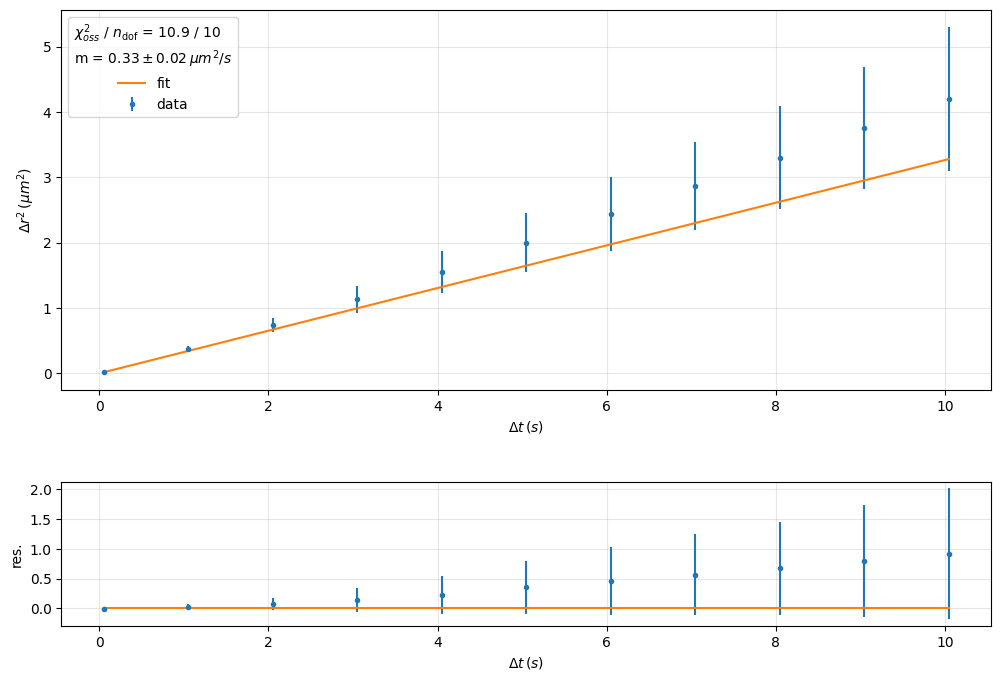

In [1283]:
# ---- Grafico con il fit e residui ----
x_fit = np.linspace(x.min(), x.max(), num=200)
y_fit = model_lin(x_fit, *m_lin.values)
res_lin = y - model_lin(x, *m_lin.values)

plt.figure(figsize=(12,8),dpi=100)
gs = gridspec.GridSpec(8, 1)
ax0 = plt.subplot(gs[:5, :])
ax1 = plt.subplot(gs[6:, :])
ax0.errorbar(x, y, err_y, fmt=".", label="data")
ax0.plot(x_fit, y_fit, label="fit")
ax0.set_xlabel('$\\Delta t \\, (s)$')
ax0.set_ylabel('$\\Delta r^2 \\, (\\mu m^2)$')
ax1.errorbar(x, res_lin, err_y, fmt=".")
ax1.plot([x.min(),x.max()], [0,0])
ax1.set_xlabel('$\\Delta t \\, (s)$')
ax1.set_ylabel('res.')
ax0.grid(alpha=0.3)
ax1.grid(alpha=0.3)

fit_info = [ f"$\\chi_{{oss}}^2$ / $n_\\mathrm{{dof}}$ = {m_lin.fval:.1f} / {len(x) - m_lin.nfit}" ]
for p, v, e in zip(m_lin.parameters, m_lin.values, m_lin.errors):
    fit_info.append(f"{p} = ${v:.2f} \\pm {e:.2f} \\, \\mu m^2/s$")
ax0.legend(title="\n".join(fit_info), loc='upper left')

plt.show()

par = 10.00; [3.25, 20.48]


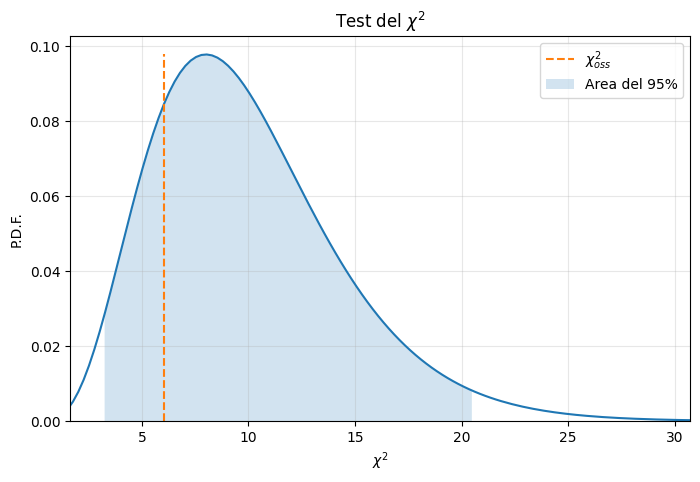

In [1267]:
def interval_sym_tails(ddof):
    p_lo = (1 - cl)/2
    p_hi = 1 - p_lo

    model = chi2(ddof)
    x_lo = model.ppf(p_lo)
    x_hi = model.ppf(p_hi)
    mode = max(ddof - 2, 0)
    return ddof, x_lo, x_hi, mode

cl = .95
ddof = len(x) - m_lin.nfit
model = chi2(ddof)

xrange=(0, 50)
xchi = np.linspace(xrange[0], xrange[1], 200)
ychi = model.pdf(xchi)

ddof, x_lo, x_hi, mode = interval_sym_tails(ddof)

print("par = {:.2f}; [{:.2f}, {:.2f}]".format(ddof, x_lo, x_hi))
x_ab = np.linspace(x_lo, x_hi, 100)
y_ab = model.pdf(x_ab)

plt.figure(figsize=(8,5),dpi=100)
plt.plot(xchi, ychi)
plt.plot([m_lin.fval,m_lin.fval], [0, model.pdf(mode)], label='$\\chi^2_{oss}$', linestyle='--')
plt.fill_between(x_ab, y_ab, alpha=0.2, label='Area del 95%')
plt.xlim(x_lo*0.5, x_hi*1.5)
plt.ylim(0)
plt.xlabel('$\\chi^2$')
plt.ylabel('P.D.F.')
plt.grid(alpha=0.3)
plt.title('Test del $\\chi^2$')
plt.legend()
plt.show()

In [ ]:
m = m_lin.values[0]*(1e-6)**2      # m^2/s
err_m = m_lin.errors[0]*(1e-6)**2  # m^2/s
T = T + 273.15                     # K
R = 2.31*1e-6                      # m
ETA = ETA*1e-6                     # Pa s

rel_err_m = err_m/m
rel_err_ETA = ETA/ERR_ETA
rel_err_R = 0.02
rel_err_T = 0.01

rel_err_tot = np.sqrt(rel_err_m**2 + rel_err_ETA**2 + rel_err_R**2 + rel_err_T**2)
      
kB = (m*6*np.pi*ETA*R) / (4*T)
err_kB = kB * rel_err_tot
rel_err_kB = err_kB/kB

kB_real = 1.381e-23

print(f"Valore misurato: kB = {kB} ± {err_kB} J/K")
print(f"Valore atteso: kB = {kB_real} J/K")
print(f"T student: {abs(kB_real - kB)/err_kB}")

# Vedere T student

Valore misurato: kB = 1.3630027171789333e-23 ± 8.84942903496484e-25 J/K
Valore atteso: kB = 1.381e-23 J/K
T student: 0.20337224864969092


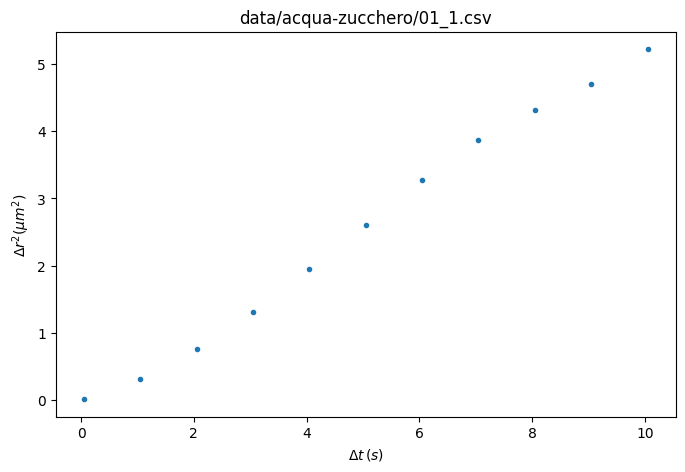

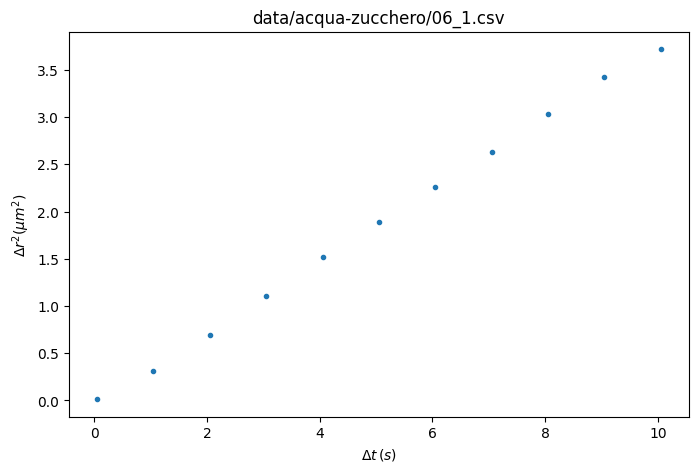

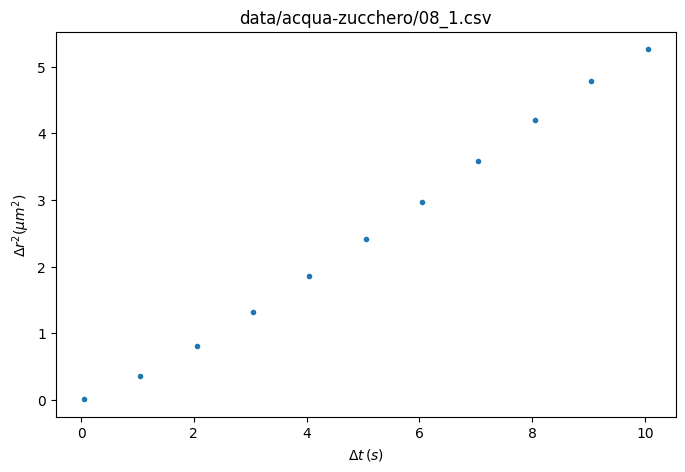

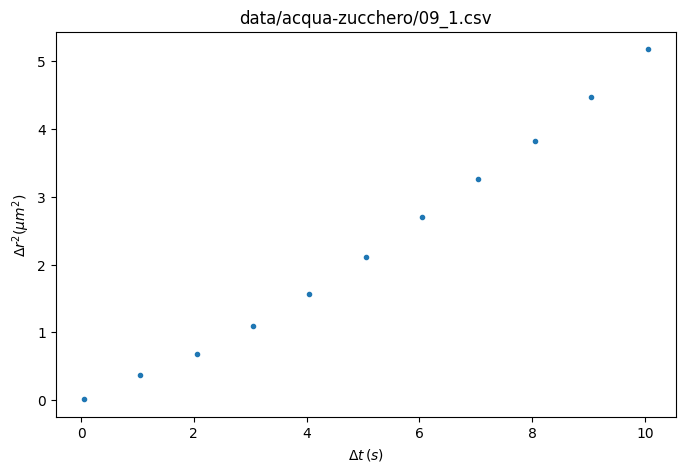

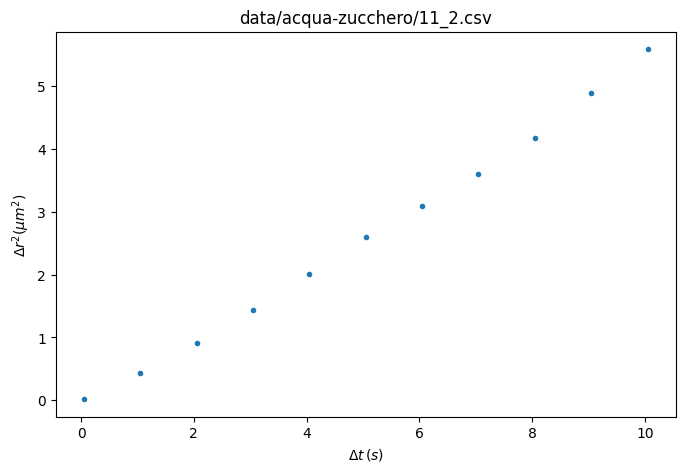

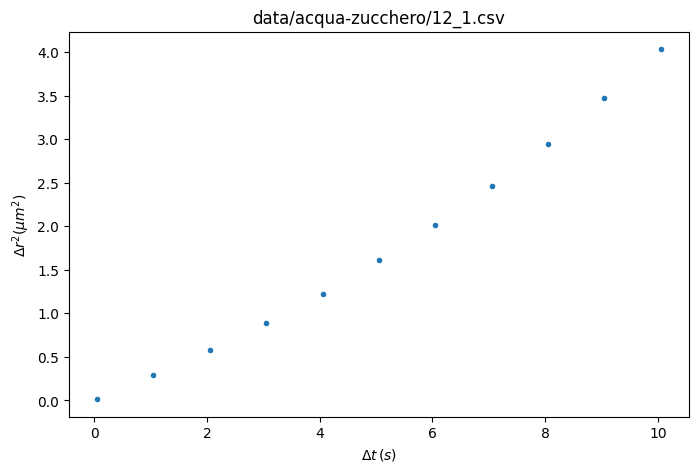

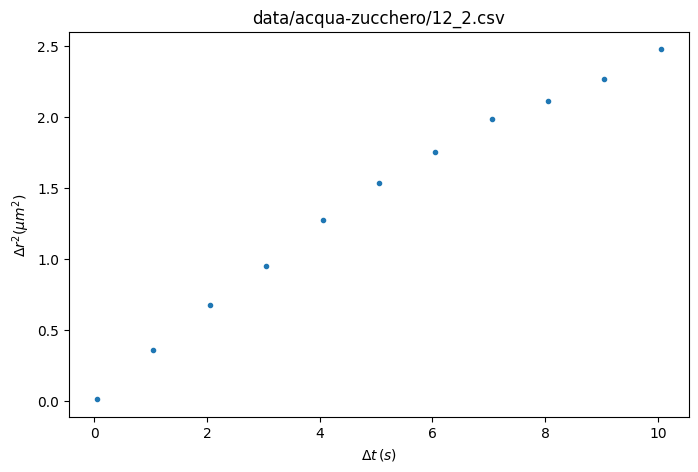

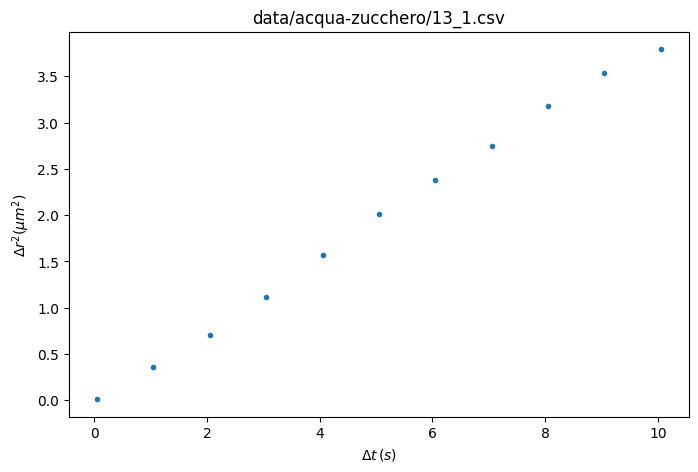

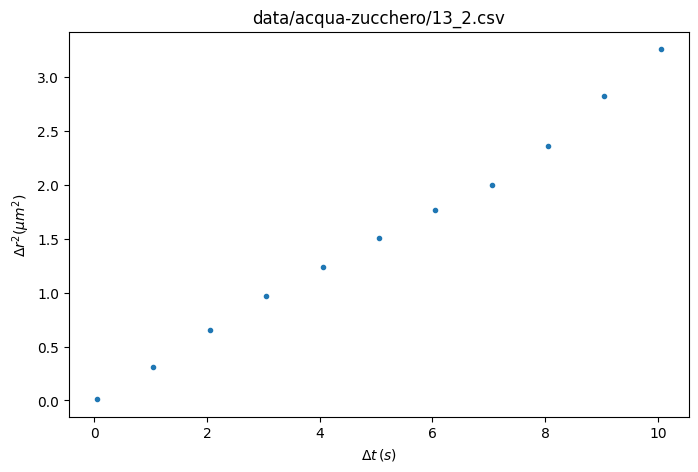

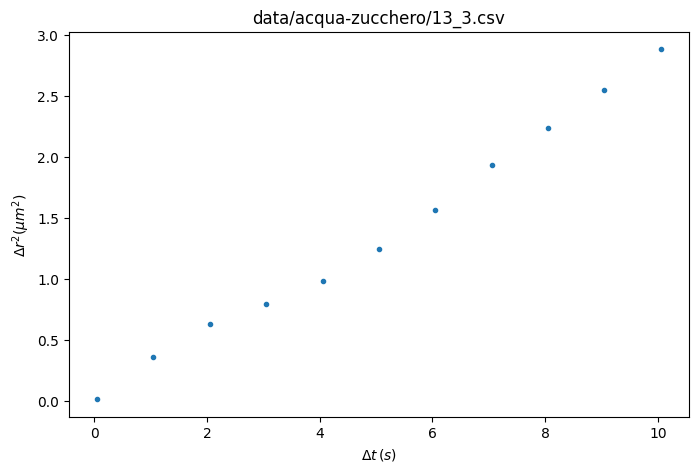

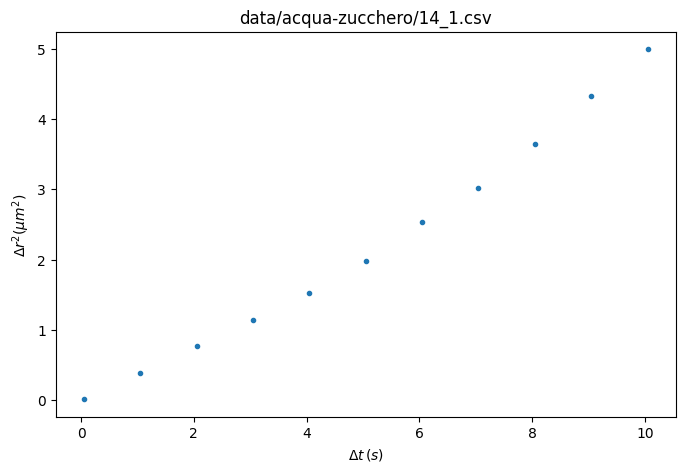

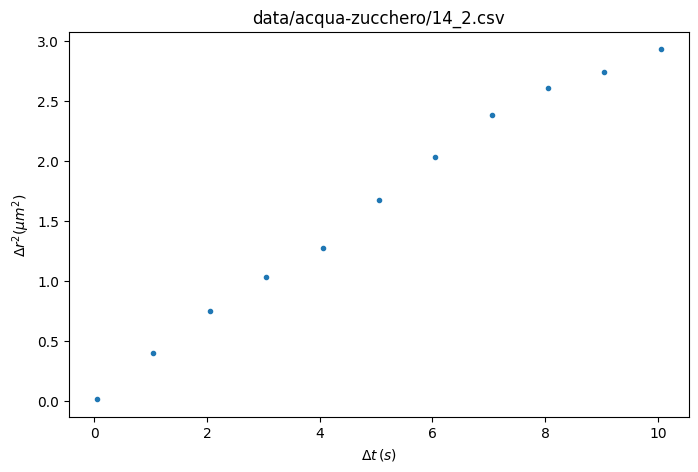

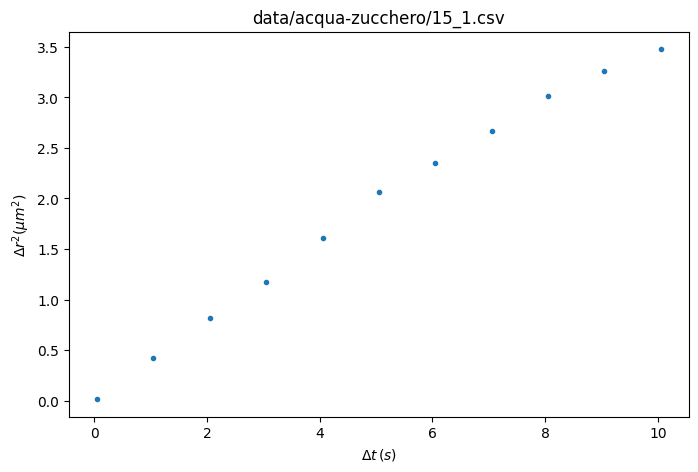

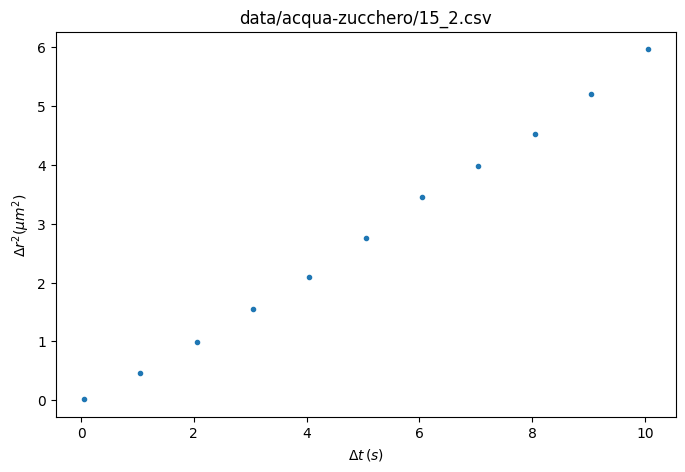

,dt,msd_1,msd_2,msd_3,msd_4,msd_5,msd_6,msd_7,msd_8,msd_9,msd_10,msd_11,msd_12,msd_13,msd_14
0,0.05,0.012733,0.012952,0.012418,0.013721,0.015315,0.013663,0.013806,0.012337,0.011527,0.014433,0.013852,0.015021,0.013896,0.015851
1,1.05,0.319122,0.306600,0.364455,0.371139,0.440788,0.297339,0.359588,0.357055,0.306914,0.364225,0.393521,0.396098,0.417705,0.465580
2,2.05,0.757606,0.689490,0.812286,0.682216,0.906563,0.580389,0.679961,0.710197,0.657616,0.630581,0.768109,0.746565,0.813411,0.986093
3,3.05,1.315484,1.101114,1.325097,1.090114,1.443364,0.883614,0.954136,1.115789,0.964750,0.797055,1.146280,1.032266,1.175672,1.544396
4,4.05,1.943720,1.513981,1.863599,1.559390,2.003686,1.224504,1.274071,1.570952,1.234642,0.987765,1.518886,1.269954,1.605767,2.088830
5,5.05,2.604043,1.886678,2.412564,2.115334,2.606340,1.611829,1.536171,2.008452,1.510698,1.245309,1.986812,1.670810,2.061050,2.760486
6,6.05,3.275228,2.265109,2.970894,2.699777,3.088051,2.011525,1.755060,2.374696,1.762796,1.562841,2.532139,2.035545,2.353978,3.452933
7,7.05,3.867918,2.633451,3.588420,3.256555,3.598322,2.459254,1.988159,2.749132,1.993530,1.939069,3.022738,2.377389,2.670844,3.989303
8,8.05,4.312991,3.030398,4.192797,3.820756,4.172262,2.946909,2.117139,3.176458,2.356026,2.239207,3.638649,2.603681,3.018107,4.524613
9,9.05,4.707693,3.427393,4.788743,4.472484,4.891407,3.476251,2.268670,3.531939,2.826795,2.549976,4.324248,2.741837,3.260334,5.197866


In [1269]:
INPUT_DIR = "data/acqua-zucchero"

df = None 

for i, input_file_name in enumerate(sorted(os.listdir(INPUT_DIR))):
    input_file_path = os.path.join(INPUT_DIR, input_file_name)

    msd, dt = msd_calculation(input_file_path, max_lag)

    plt.figure(figsize=(8,5))
    plt.plot(dt, msd, '.')
    plt.xlabel('$\\Delta t \\, (s)$')
    plt.ylabel('$\\Delta r^2 (\\mu m^2)$')
    plt.title(input_file_path)
    plt.show()

    col_name = f"msd_{i+1}"  # oppure usa il nome del file

    if df is None:
        # prima iterazione: crea il DataFrame con dt
        df = pd.DataFrame({
            "dt": dt,
            col_name: msd
        })
    else:
        # aggiunge solo la nuova colonna msd
        df[col_name] = msd

df

In [1270]:
df["msd_mean"] = df.drop(columns="dt").mean(axis=1)
df["msd_sem"] = df.drop(columns="dt").std(axis=1)
df

,dt,msd_1,msd_2,msd_3,msd_4,msd_5,msd_6,msd_7,msd_8,msd_9,msd_10,msd_11,msd_12,msd_13,msd_14,msd_mean,msd_sem
0,0.05,0.012733,0.012952,0.012418,0.013721,0.015315,0.013663,0.013806,0.012337,0.011527,0.014433,0.013852,0.015021,0.013896,0.015851,0.013680,0.001174
1,1.05,0.319122,0.306600,0.364455,0.371139,0.440788,0.297339,0.359588,0.357055,0.306914,0.364225,0.393521,0.396098,0.417705,0.465580,0.368581,0.049162
2,2.05,0.757606,0.689490,0.812286,0.682216,0.906563,0.580389,0.679961,0.710197,0.657616,0.630581,0.768109,0.746565,0.813411,0.986093,0.744363,0.105022
3,3.05,1.315484,1.101114,1.325097,1.090114,1.443364,0.883614,0.954136,1.115789,0.964750,0.797055,1.146280,1.032266,1.175672,1.544396,1.134938,0.204655
4,4.05,1.943720,1.513981,1.863599,1.559390,2.003686,1.224504,1.274071,1.570952,1.234642,0.987765,1.518886,1.269954,1.605767,2.088830,1.547125,0.319753
5,5.05,2.604043,1.886678,2.412564,2.115334,2.606340,1.611829,1.536171,2.008452,1.510698,1.245309,1.986812,1.670810,2.061050,2.760486,2.001184,0.446759
6,6.05,3.275228,2.265109,2.970894,2.699777,3.088051,2.011525,1.755060,2.374696,1.762796,1.562841,2.532139,2.035545,2.353978,3.452933,2.438612,0.572462
7,7.05,3.867918,2.633451,3.588420,3.256555,3.598322,2.459254,1.988159,2.749132,1.993530,1.939069,3.022738,2.377389,2.670844,3.989303,2.866720,0.676226
8,8.05,4.312991,3.030398,4.192797,3.820756,4.172262,2.946909,2.117139,3.176458,2.356026,2.239207,3.638649,2.603681,3.018107,4.524613,3.296428,0.786580
9,9.05,4.707693,3.427393,4.788743,4.472484,4.891407,3.476251,2.268670,3.531939,2.826795,2.549976,4.324248,2.741837,3.260334,5.197866,3.747545,0.934130


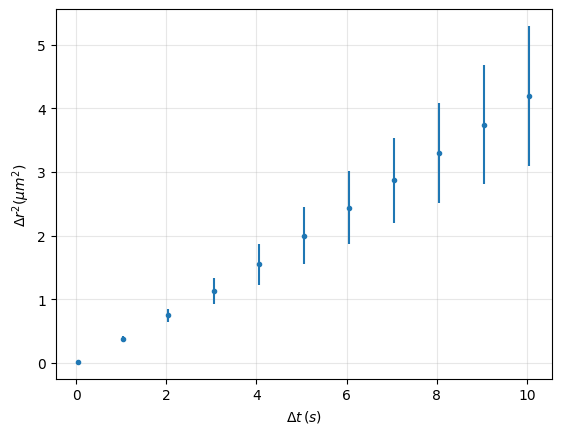

In [1271]:
x = df["dt"]
y = df["msd_mean"]
err_y = df["msd_sem"]

# plt.figure(figsize=(8,5))
plt.errorbar(x, y, yerr=err_y, fmt='.')
plt.xlabel('$\\Delta t \\, (s)$')
plt.ylabel('$\\Delta r^2 (\\mu m^2)$')
plt.grid(alpha=0.3)
plt.show()

In [1272]:
least_squares_mode_lin = LeastSquares(x, y, err_y, model_lin)
m_lin = Minuit(least_squares_mode_lin, 1000, name=("m"))
m_lin.migrad()
m_lin.hesse()
m_lin.minos()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 10.92 (χ²/ndof = 1.1)      │              Nfcn = 22               │
│ EDM = 5.14e-11 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ m    │   0.326   │   0.017   │   -0.017   │   0.017    │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │           m           │
├──────────┼───────────┬───────────┤
│  Error   │  -0.017   │   0.017   │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───┬──────────┐
│   │        m │
├───┼──────────┤
│ m │ 0.000273 │
└───┴──────────┘

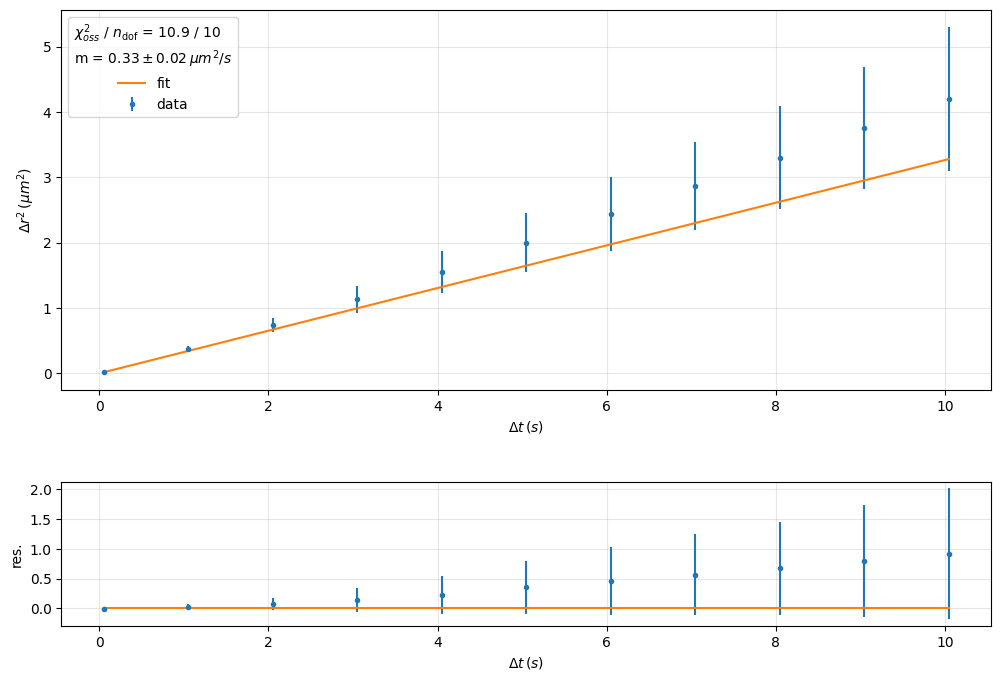

In [1276]:
# ---- Grafico con il fit e residui ----
x_fit = np.linspace(x.min(), x.max(), num=200)
y_fit = model_lin(x_fit, *m_lin.values)
res_lin = y - model_lin(x, *m_lin.values)

plt.figure(figsize=(12,8),dpi=100)
gs = gridspec.GridSpec(8, 1)
ax0 = plt.subplot(gs[:5, :])
ax1 = plt.subplot(gs[6:, :])
ax0.errorbar(x, y, err_y, fmt=".", label="data")
ax0.plot(x_fit, y_fit, label="fit")
ax0.set_xlabel('$\\Delta t \\, (s)$')
ax0.set_ylabel('$\\Delta r^2 \\, (\\mu m^2)$')
ax1.errorbar(x, res_lin, err_y, fmt=".")
ax1.plot([x.min(),x.max()], [0,0])
ax1.set_xlabel('$\\Delta t \\, (s)$')
ax1.set_ylabel('res.')
ax0.grid(alpha=0.3)
ax1.grid(alpha=0.3)

fit_info = [ f"$\\chi_{{oss}}^2$ / $n_\\mathrm{{dof}}$ = {m_lin.fval:.1f} / {len(x) - m_lin.nfit}" ]
for p, v, e in zip(m_lin.parameters, m_lin.values, m_lin.errors):
    fit_info.append(f"{p} = ${v:.2f} \\pm {e:.2f} \\, \\mu m^2/s$")
ax0.legend(title="\n".join(fit_info), loc='upper left')

plt.show()

par = 10.00; [3.25, 20.48]


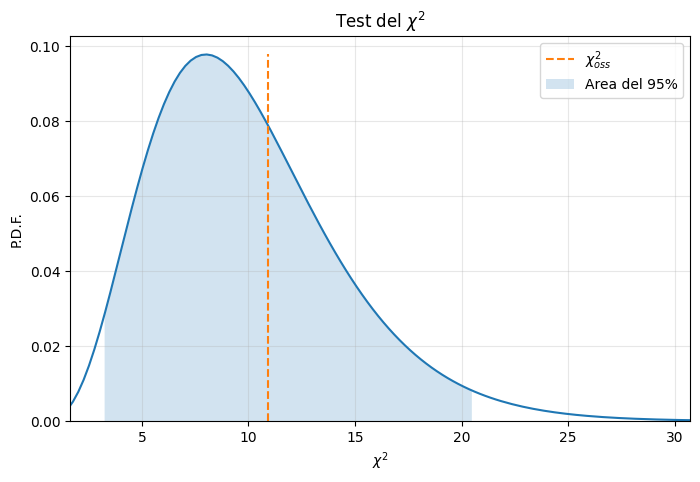

In [1280]:
def interval_sym_tails(ddof):
    p_lo = (1 - cl)/2
    p_hi = 1 - p_lo

    model = chi2(ddof)
    x_lo = model.ppf(p_lo)
    x_hi = model.ppf(p_hi)
    mode = max(ddof - 2, 0)
    return ddof, x_lo, x_hi, mode

cl = .95
ddof = len(x) - m_lin.nfit
model = chi2(ddof)

xrange=(0, 50)
xchi = np.linspace(xrange[0], xrange[1], 200)
ychi = model.pdf(xchi)

ddof, x_lo, x_hi, mode = interval_sym_tails(ddof)

print("par = {:.2f}; [{:.2f}, {:.2f}]".format(ddof, x_lo, x_hi))
x_ab = np.linspace(x_lo, x_hi, 100)
y_ab = model.pdf(x_ab)

plt.figure(figsize=(8,5),dpi=100)
plt.plot(xchi, ychi)
plt.plot([m_lin.fval,m_lin.fval], [0, model.pdf(mode)], label='$\\chi^2_{oss}$', linestyle='--')
plt.fill_between(x_ab, y_ab, alpha=0.2, label='Area del 95%')
plt.xlim(x_lo*0.5, x_hi*1.5)
plt.ylim(0)
plt.xlabel('$\\chi^2$')
plt.ylabel('P.D.F.')
plt.grid(alpha=0.3)
plt.title('Test del $\\chi^2$')
plt.legend()
plt.show()

In [1275]:
m = m_lin.values[0]*(1e-6)**2      # m^2/s
err_m = m_lin.errors[0]*(1e-6)**2  # m^2/s

rel_err_m = err_m/m
rel_err_tot = np.sqrt(rel_err_kB**2 + rel_err_T**2 + rel_err_m**2 + rel_err_R**2)
eta_sugar = (4 * kB * T)/(6 * np.pi * m * R) * 1e6
err_eta_sugar = eta_sugar * rel_err_tot 

print(f"Valore misurato: η = {eta_sugar:.2f} ± {err_eta_sugar:.2f} μPa s")
print(f"Errore relativo: {err_eta_sugar/eta_sugar * 100:.2f} %")

Valore misurato: η = 1144.37 ± 97.65 μPa s
Errore relativo: 8.53 %
